# 4. Performance of payload

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
from scipy.stats import binned_statistic
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from scipy.ndimage import median_filter
from matplotlib import patches
from matplotlib.ticker import FuncFormatter

# PlatoSim extra
import natsort
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot       as pt
import platosim.noise      as ns
import platosim.utilities  as ut
import platosim.statistics as st
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

import warnings
warnings.simplefilter("ignore")

In [3]:
# Define paths
fdir = '/lhome/nicholas/Nextcloud/paperMOCKA/figures'
path = f'/lhome/nicholas/software/workdir/mocka/simulations/analysis/GDOR_mag17'

## Plot light curve

In [22]:
star = f'{1}'.zfill(9)
idir = f'{path}/output_clean/{star}'

# Load ligth curve object
lcs = LightCurve(idir, 'multi')
N = len(lcs.files('ftr')) / 2.

# Simulation table
lc = LightCurve(lcs.files('ftr')[0])
ds = lc.star()
ds

ID                           1
gaiaDR3    5303012479913170560
ra                  134.532937
dec                 -60.020178
mag                  15.316477
group                        1
camera                       1
quarter                      1
ccd                          2
xCCD               1851.767959
yCCD                800.446693
rOA                  17.148201
xFP                  -68.07196
yFP                 -34.631823
ncon                         3
SPR                   0.000159
Name: 0, dtype: object

In [23]:
# Check predicted NSR camera and mission level
tdur = 3600
noise_jitter         = ut.getJitterNoiseLimitNSR(rms=0.037, tdur=tdur, level='camera')
noise_photon_camera  = ut.getPhotonNoiseLimitNSR(ds.mag, passband='P', ncam=1, tdur=tdur)
noise_photon_mission = ut.getPhotonNoiseLimitNSR(ds.mag, passband='P', ncam=N, tdur=tdur)
noise_background     = ut.getBackgroundNoiseLimitNSR(ds.mag, passband='P', tdur=tdur)
noise_camera  = noise_jitter + noise_photon_camera  + noise_background
noise_mission = noise_jitter + noise_photon_mission + noise_background

# print(f'Max ampl    : {dp.Amax_mag[0] * 1.037e6:.0f} ppm')
print(f'NSR camera  : {noise_camera:.0f} ppm')
print(f'NSR mission : {noise_mission:.0f} ppm ({int(N)} N-CAM)')

NSR camera  : 3261 ppm
NSR mission : 2662 ppm (6 N-CAM)


<IPython.core.display.Javascript object>


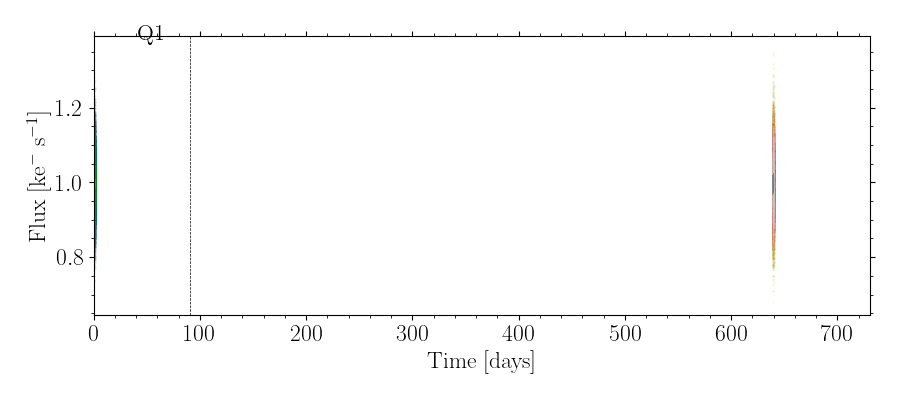

In [24]:
fig, ax = lcs.plot_multi(suffix='ftr', group=False, camera=False, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,4))

---
## NSR vs. P magnitude
---

### NSR(P) at camera level

In [4]:
lcs = LightCurve(f'{path}/output_clean', mode="multi")
ofile = f'{path}/nsr_per_camera_BOL.ftr'
# lcs.run_NSRvsMag_analysis_perCamera(ofile, suffix="ftr", quarter=8);

<IPython.core.display.Javascript object>


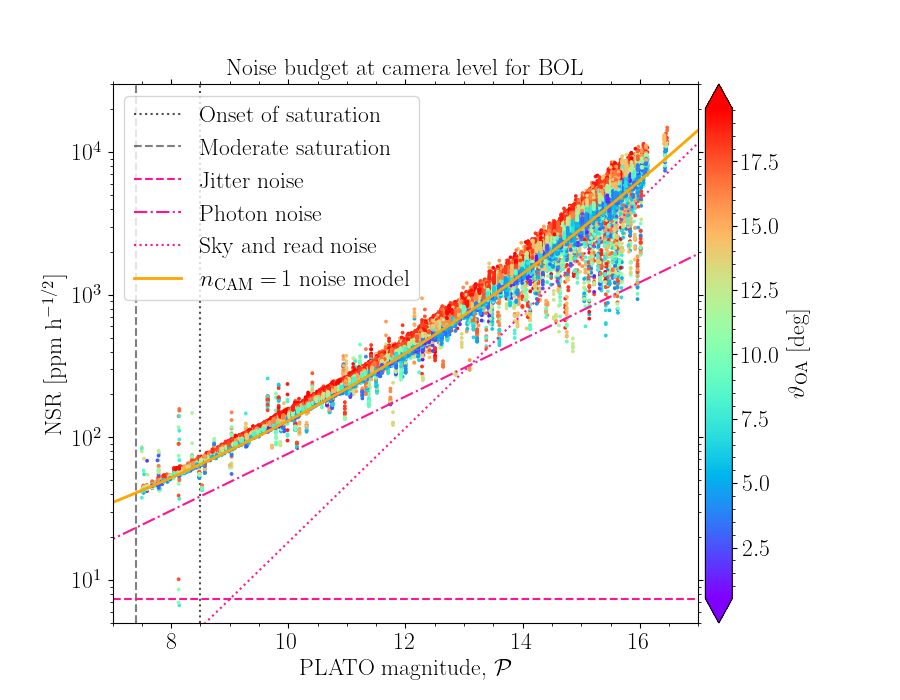

In [6]:
# Load results
ofile = f'{path}/nsr_per_camera_BOL.ftr'
df = pd.read_feather(ofile)

# Order after contaminants
df = df.sort_values(by=['SPR'], ascending=False)
# df = df[df.SPR == 0]

# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, column="rOA", passband='P', residuals="multi", 
                                show_ncam_noise_limits=1, show_saturation_limits=True,
                                show_targets=True, legend=True, grid=False, 
                                cmap='rainbow', figsize=(9, 7))
# Settings
ax.set_title('Noise budget at camera level for BOL')
ax.set_xlim(7.0, 17)
ax.set_ylim(5, 3e4)
plt.legend(loc='upper left');

# Save figure
fig.savefig(f'{fdir}/nsr_camera_BOL_rOA.png', bbox_inches='tight', dpi=300);

### NSR(P) at mission level

In [4]:
lcs = LightCurve(f'{path}/output_clean', mode="multi")
ofile = f'{path}/nsr_per_star_BOL.ftr'
# lcs.run_NSRvsMag_analysis_perStar(ofile, suffix="ftr", quarter=1);

<IPython.core.display.Javascript object>


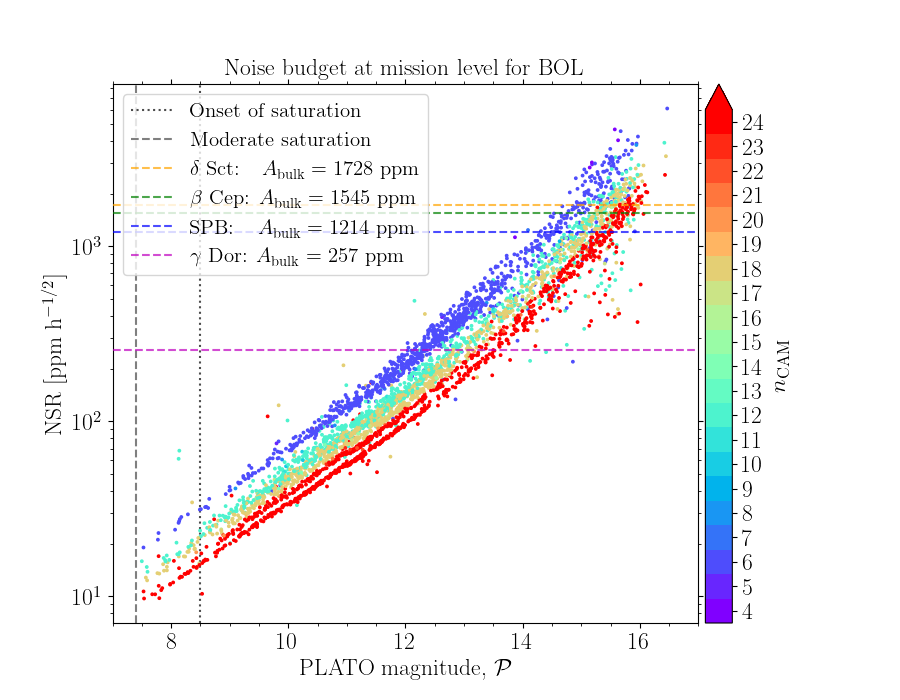

In [13]:
# Load results
df = pd.read_feather(ofile)

# Order after contaminants
df = df.sort_values(by=['SPR'], ascending=False)
# df = df[df.SPR > 0.2]
# print(df.shape[0])

# df.mag = ut.passbandConversionV2P(df.mag, 6000, inverse=True, method='fialho')

# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, column="ncam", passband='P', residuals=False, 
                                show_ncam_noise_limits=False, show_saturation_limits=True,
                                show_targets=True, legend=True, grid=False, 
                                cmap='rainbow', figsize=(9, 7))

# Plot detection limits of typical amplitudes
# ax.axhline(y=10000, color="m", alpha=0.7, linestyle='-.', 
#            zorder=5, label=r'$\gamma$ Dor: $\; A_{\rm max} = 10$ ppt')
ax.axhline(y=1728, color="orange", alpha=0.7, linestyle='--',
          zorder=5, label=r'$\delta$ Sct: \, $A_{\rm bulk} = 1728$ ppm')
ax.axhline(y=1545, color="g", alpha=0.7, linestyle='--',
          zorder=5, label=r'$\beta$ Cep: $A_{\rm bulk} = 1545$ ppm')
ax.axhline(y=1214, color="b", alpha=0.7, linestyle='--',
          zorder=5, label=r'SPB: \,\,\, $A_{\rm bulk} = 1214$ ppm')
ax.axhline(y=257, color="m", alpha=0.7, linestyle='--',
          zorder=5, label=r'$\gamma$ Dor: $A_{\rm bulk} = 257$ ppm')

# Settings
ax.set_title('Noise budget at mission level for BOL')
ax.set_xlim(7.0, 17)
# ax.set_ylim(0, 20000)
plt.legend();

# Save figure
fig.savefig(f'{fdir}/nsr_mission_ncam.png', bbox_inches='tight', dpi=300);

## Testing space

In [ ]:
# Test single light curve
files_final = natsort.natsorted(glob.glob(f'{path}/clean/final/*'))
lc = LightCurve(files_final[0], mode="single")

df = lc.bin_lc(tbin=600, t0=0, t1=1)
noise = (1 - df.flux) * 1e6
NSR = np.std(noise) / np.sqrt(86400/600)
NSR

In [ ]:
def getReducedNSR(path):
    
    idir = '/lhome/nicholas/software/workdir/mocka'
    folders = natsort.natsorted(glob.glob(f'{path}/*'))
    dx = pd.DataFrame()
    
    for f,i in zip(folders, range(len(folders))):
        
        # Load and reduce light curve
        star = Path(folders[i]).stem
        try:
            lcs = LightCurve(f, 'multi')
        except: 
            pass
        else:
            lc = lcs.merge(suffix='hdf5', 
                   verbose=True,
                   detrend='poly',
                   flux_group_mean=True, 
                   clip=False, #df.mag.iloc[0], 
                   binsize=0.2, 
                   flux_offset=True, 
                   flux_err=True, 
                   ofile=f'{path}/lc_{star}.ftr')

            # Introduce data gaps
            df = lc.gaps(f'{idir}/input/instrumentGAP.tab', replace=True)
            df = df.dropna()
            df.time /= 86400

            # Load variable template
            dp = pd.read_feather(f'{f}/../../varsource/{star}/varsource_001_parameters.ftr')
            dm = pd.read_feather(f'{f}/../../varsource/{star}/varsource_001_pulsations.ftr')
            dv = pd.DataFrame()
            dv['time'] = df.time
            dv['dmag'] = ns.timeSeriesFromFourier(df.time, dm.freq, dm.ampl, dm.phase, power=2.2)
            dv['flux'] = (10**(-0.4*dv.dmag) - 1) * 1e3

            # Compute the residuals
            df['flux_res'] = (df.flux -1)*1e3 - dv.flux

            # Compute NSR for star
            NSR_res = np.std(df.flux_res) * 1e3
            RMS_res = ut.medianAbsoluteDeviation(df.flux_res) * 1e3 

            
            # Store in data frame
            dx0 = pd.DataFrame({'Pmag': dp.Pmag,
                                'NSR': NSR,
                                'ncam': dt.shape[0]/8,
                                'rOA': dt.rOA.mean(),
                                'SPR': dt.SPR.mean(),
                                })
            dx = pd.concat([dx, dx0])

    return dx
        
# RUN SCRIPT
idir = f'/lhome/nicholas/software/workdir/mocka/simulations/tests/test_hdf5'
# df = getReducedNSR(idir)

In [ ]:
def getNSR(path, sample='affogato'):
    
    # Load light curve object for the first star only and unpack the data
    pathv = f'{path}/varsource'
    files_param = natsort.natsorted(glob.glob(f'{path}/varsource/parameters/*'))
    files_pulsa = natsort.natsorted(glob.glob(f'{path}/varsource/pulsations/*'))
    files_table = natsort.natsorted(glob.glob(f'{path}/{sample}/table/*'))
    files_final = natsort.natsorted(glob.glob(f'{path}/{sample}/final/*'))
    dx = pd.DataFrame()
    
    for i in tqdm(range(len(files_final)), bar_format=ut.tqdmBar()):
        
        # Load files from for varsource
        dp = pd.read_feather(files_param[i])
        dt = pd.read_feather(files_table[i])
        dm = pd.read_feather(files_pulsa[i])
        
        # Load data and bin
        try:
            lc = LightCurve(files_final[i], mode="single")
        except: 
            pass
        else:
            # Bin data
            df = lc.bin_lc(tbin=600, t0=0, t1=100)
            df.time /= 86400
            df.flux = (df.flux - 1) * 1e6

            # Load variable template
            df['dmag_var'] = ns.timeSeriesFromFourier(df.time, dm.freq, dm.ampl, dm.phase, power=2.2)
            df['flux_var'] = (10**(-0.4*df.dmag_var) - 1) * 1e6
            
            # Compute residuals
            df['flux_res'] = df.flux - df.flux_var   
            df = df.dropna()
            NSR = ut.medianAbsoluteDeviation(df.flux_res.to_numpy())

            # Store in data frame
            dx0 = pd.DataFrame({'Pmag': dp.Pmag,
                                'NSR': NSR,
                                'ncam': dt.shape[0]/8,
                                'rOA': dt.rOA.mean(),
                                'SPR': dt.SPR.mean(),
                               })
            dx = pd.concat([dx, dx0])

    # Return data frame
    return dx


# Fetch NSR for all stars
path = f'/lhome/nicholas/software/workdir/mocka/simulations/analysis/GDOR'
# path = f'/lhome/nicholas/software/workdir/mocka/simulations/output_clean'
df = getNSR(path, 'clean')

In [12]:
def getNSR(project, data_dir):
    
    """NSR estimate from fully reduced feather light curves.
    """
    
    # Define paths and 
    path = Path(os.getenv('PLATO_WORKDIR')) / project
    idir = path / 'input'
    sdir = path / data_dir
    vdir = sdir.parents[0] / 'varsource'
    
    # Fetch filenames
    files = natsort.natsorted(glob.glob(f'{sdir}/lc_**.ftr'))
    dx = pd.DataFrame()
    
    for file_i, i in zip(files, tqdm(range(len(files)), bar_format=ut.tqdmBar())):
        
        # Load and reduce light curve
        f = Path(file_i)
        star = f.stem[3:]
        lc = LightCurve(f, 'single')
        
        # Introduce data gaps
        df = lc.data().dropna()
        
        # Load variable template
        dp = pd.read_feather(vdir / f'parameters/parameters_{star}_001.ftr')
        dm = pd.read_feather(vdir / f'pulsations/pulsations_{star}_001.ftr')
        dv = pd.DataFrame()
        dv['time'] = df.time
        dv['dmag'] = ns.timeSeriesFromFourier(df.time, dm.freq, dm.ampl, dm.phase, power=2.2)
        dv['flux'] = (10**(-0.4*dv.dmag) - 1) * 1e6
        
        # Compute the residuals
        df['flux'] = (df.flux - 1) * 1e6 #- dv.flux
        lc = LightCurve(df, 'multi')    
        NSR = lc.getNSR(influx='ppm', unit='ppm', binhour=1)
        
        # Store in data frame
        dx0 = pd.DataFrame({'Pmag': dp.Pmag,
                            'NSR': NSR,
                            'ncam': dp['ncams'],
                            'ID': star,
#                             'rOA': dp.rOA.mean(),
#                             'SPR': dp.SPR.mean(),
                            })
        dx = pd.concat([dx, dx0])

    return dx
        
# RUN SCRIPT
idir = 'simulations/analysis/GDOR/feather_clean'
df = getNSR(project='mocka', data_dir=idir)

 98%|████████████████████████████████████████████████▊ | 39/40 [03:07<00:04,  4.
